In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, glob, os, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
SEED = 42

In [2]:
# Auto-discover saved models
churn_files     = sorted(glob.glob('models/churn_*.pkl'))
sentiment_files = sorted(glob.glob('models/sentiment_*.pkl'))

print('Churn models found:')
for f in churn_files: print(' ', f)
print('\nSentiment models found:')
for f in sentiment_files: print(' ', f)

churn_candidates     = {f: joblib.load(f) for f in churn_files}
sentiment_candidates = {f: joblib.load(f) for f in sentiment_files}

print(f'\nLoaded {len(churn_candidates)} churn model(s), {len(sentiment_candidates)} sentiment model(s)')

Churn models found:
  models\churn_gradient_boosting.pkl
  models\churn_logistic_regression.pkl
  models\churn_random_forest.pkl
  models\churn_xgboost.pkl

Sentiment models found:
  models\sentiment_linear_svm.pkl
  models\sentiment_logistic_regression.pkl
  models\sentiment_naive_bayes.pkl
  models\sentiment_random_forest.pkl



Loaded 4 churn model(s), 4 sentiment model(s)


In [3]:
# Load churn_model.ipynb's own validation/test splits directly — they now persist
# Customer_ID (see that notebook's §1) — and join back to Churn.csv purely to attach
# each customer's Review. No split logic is re-derived here.
ID_COL   = 'Customer_ID'
TAB_COLS = ['Account_Age_Days', 'Daily_Usage_Mins', 'Support_Tickets_90Days',
            'API_Utilization_Rate', 'Support_Ticket_Friction', 'Login_Frequency', 'Plan_Tier']
TEXT_COL = 'Review'
TARGET   = 'Churn'

raw = pd.read_csv('Datasets/Churn.csv')
raw = raw[raw['Churn'].astype(str).isin(['0', '1'])].reset_index(drop=True)
ticket_lookup = raw[[ID_COL, TEXT_COL]]

val  = pd.read_csv('Datasets/validation_churn.csv').merge(ticket_lookup, on=ID_COL, how='left')
test = pd.read_csv('Datasets/test_churn.csv').merge(ticket_lookup, on=ID_COL, how='left')

assert val[TEXT_COL].notna().all() and test[TEXT_COL].notna().all(), 'Unmatched Customer_ID in join'

print(f'Validation: {val.shape}  ({len(val)} rows)')
print(f'Test:       {test.shape}  ({len(test)} rows)')

X_val_tab,   y_val   = val[TAB_COLS],  val[TARGET]
X_test_tab,  y_test  = test[TAB_COLS], test[TARGET]
X_val_text,  X_test_text  = val[TEXT_COL],  test[TEXT_COL]

val.head(3)[[ID_COL] + TAB_COLS + [TEXT_COL, TARGET]]

Validation: (375, 10)  (375 rows)
Test:       (376, 10)  (376 rows)


,Customer_ID,Account_Age_Days,Daily_Usage_Mins,Support_Tickets_90Days,API_Utilization_Rate,Support_Ticket_Friction,Login_Frequency,Plan_Tier,Review,Churn
0,db1cc72c-6040-43bb-91c7-c5cee0103a56,993,3,1,0.16,0.250000,Weekly,Enterprise,The reliability of the export tool over the pa...,1
1,9a9eac8a-dc87-4d14-92c2-8c7d657e528c,541,92,3,0.46,0.032258,Daily,Pro,The export tool has been broken for the past m...,0
2,1b93c0e3-4f3e-4f80-b1e8-e26195dffe14,710,51,4,0.46,0.076923,Weekly,Basic,We noticed notification delays on the integrat...,0


In [4]:
# ── Best churn model, by validation F2 Score ─────────────────────────────────
# Matches churn_model.ipynb's own selection criterion: catching likely churners
# matters more than avoiding false alarms, so recall is weighted 4x precision
# (beta=2) at the standard 0.5 decision threshold.
best_f2, best_churn_path, best_churn_model = 0, None, None
for path, model in churn_candidates.items():
    proba = model.predict_proba(X_val_tab)[:, 1]
    pred = (proba >= 0.5).astype(int)
    f2 = fbeta_score(y_val, pred, beta=2)
    print(f'  {os.path.basename(path):<40} F2={f2:.4f}')
    if f2 > best_f2:
        best_f2, best_churn_path, best_churn_model = f2, path, model

print(f'\n>>> Best churn model (validation F2 Score): {os.path.basename(best_churn_path)}')

  churn_gradient_boosting.pkl              F2=0.8226
  churn_logistic_regression.pkl            F2=0.7765
  churn_random_forest.pkl                  F2=0.8124
  churn_xgboost.pkl                        F2=0.7631

>>> Best churn model (validation F2 Score): churn_gradient_boosting.pkl


In [5]:
# ── Best sentiment model, by weighted F1 on sentiment_model.ipynb's own validation fold ──
# Reuses validation_sentiment.csv rather than re-deriving a split of sentiment_tickets.csv,
# for the same reason §2 reuses churn_model.ipynb's split logic: it's the exact held-out
# fold that notebook's sentiment models were never trained on.
sent_val = pd.read_csv('Datasets/validation_sentiment.csv')

best_f1, best_sent_path, best_sent_model = 0, None, None
for path, model in sentiment_candidates.items():
    preds = model.predict(sent_val['review_text'])
    f1 = f1_score(sent_val['sentiment'], preds, average='weighted')
    print(f'  {os.path.basename(path):<45} F1(weighted)={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_sent_path, best_sent_model = f1, path, model

print(f'\n>>> Best sentiment model (validation weighted F1): {os.path.basename(best_sent_path)}')

  sentiment_linear_svm.pkl                      F1(weighted)=0.7376


  sentiment_logistic_regression.pkl             F1(weighted)=0.7038
  sentiment_naive_bayes.pkl                     F1(weighted)=0.7395
  sentiment_random_forest.pkl                   F1(weighted)=0.6148

>>> Best sentiment model (validation weighted F1): sentiment_naive_bayes.pkl


In [6]:
# ── Churn model → P(churn) ───────────────────────────────────────────────────
churn_proba_val  = best_churn_model.predict_proba(X_val_tab)[:, 1]
churn_proba_test = best_churn_model.predict_proba(X_test_tab)[:, 1]

# ── Sentiment model → label on support tickets ───────────────────────────────
sent_pred_val  = best_sent_model.predict(X_val_text)
sent_pred_test = best_sent_model.predict(X_test_text)

# ── Map sentiment → churn risk score [0, 1] ──────────────────────────────────
# Frustrated → high churn risk, Neutral → moderate, Satisfied → low. Rather than
# collapsing to the argmax label (which discards confidence — a 95%-confident
# Frustrated ticket and a 40%-confident one scored identically), take the
# probability-weighted expectation over SENT_SCORE. Falls back to the hard-label
# mapping if the chosen model has no predict_proba (e.g. LinearSVC).
SENT_SCORE = {'Frustrated': 1.0, 'Neutral': 0.5, 'Satisfied': 0.0}

if hasattr(best_sent_model, 'predict_proba'):
    class_scores = np.array([SENT_SCORE[c] for c in best_sent_model.classes_])
    sent_score_val  = best_sent_model.predict_proba(X_val_text)  @ class_scores
    sent_score_test = best_sent_model.predict_proba(X_test_text) @ class_scores
else:
    sent_score_val  = np.array([SENT_SCORE[s] for s in sent_pred_val])
    sent_score_test = np.array([SENT_SCORE[s] for s in sent_pred_test])

print('Sentiment distribution on TEST tickets:')
unique, counts = np.unique(sent_pred_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u}: {c} ({c/len(sent_pred_test)*100:.1f}%)')

preview = pd.DataFrame({
    'Ticket (truncated)': [t[:55] + '...' for t in X_test_text.values[:8]],
    'Sentiment':          sent_pred_test[:8],
    'Sent Score':         sent_score_test[:8].round(3),
    'Churn P(model)':     churn_proba_test[:8].round(3),
    'Actual Churn':       y_test.values[:8]
})
preview

Sentiment distribution on TEST tickets:
  Frustrated: 125 (33.2%)
  Neutral: 103 (27.4%)
  Satisfied: 148 (39.4%)


,Ticket (truncated),Sentiment,Sent Score,Churn P(model),Actual Churn
0,Budget conversations about the admin console h...,Satisfied,0.173,0.083,0
1,Our IT team asked how to set up conditional lo...,Satisfied,0.389,0.893,1
2,Our engineering lead migrated a big workload o...,Frustrated,0.521,0.008,0
3,Our department head asked how to set up condit...,Satisfied,0.073,0.107,0
4,The renewal price increase on customer support...,Frustrated,0.625,0.332,0
5,We've had repeated failed uploads on the notif...,Frustrated,0.793,0.041,0
6,Our ops lead expected better account managemen...,Satisfied,0.411,0.977,1
7,"The billing system works fine overall, though ...",Neutral,0.455,0.641,0


In [7]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        # beta=2 weights recall 4x more than precision — same priority used to pick
        # the churn model itself: catching churners matters more than false alarms.
        'F2':        round(fbeta_score(y_true, y_pred, beta=2), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC':    round(average_precision_score(y_true, y_proba), 4),
    }

val_results = []

# Baselines
val_results.append(evaluate('Churn model alone', y_val, (churn_proba_val >= 0.5).astype(int), churn_proba_val))
val_results.append(evaluate('Sentiment signal alone', y_val, (sent_score_val >= 0.5).astype(int), sent_score_val))

# Average (α=0.5)
avg_proba_val = 0.5 * churn_proba_val + 0.5 * sent_score_val
val_results.append(evaluate('Average (α=0.5)', y_val, (avg_proba_val >= 0.5).astype(int), avg_proba_val))

print('Baselines and equal-weight average scored on validation.')

Baselines and equal-weight average scored on validation.


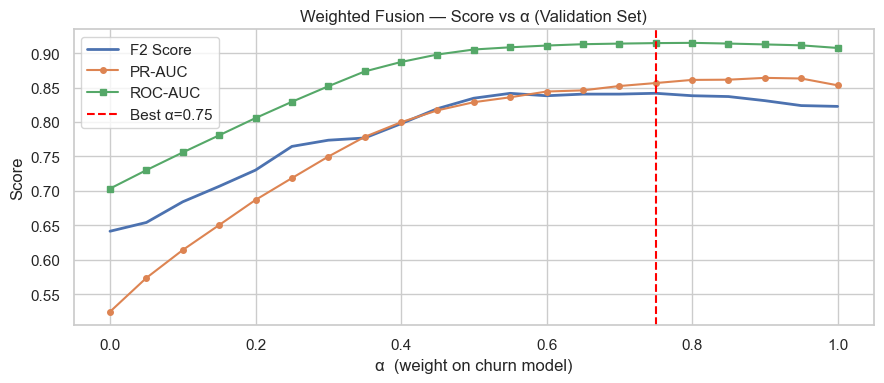

Best α=0.75  (validation F2=0.8417, PR-AUC=0.8565)


In [8]:
# ── Weighted average — sweep α on VALIDATION, rank by F2 Score ───────────────
# F2 (not PR-AUC) — matches the model-selection priority: catching churners
# matters more than avoiding false alarms, so recall is weighted 4x precision.
alphas = np.arange(0.0, 1.01, 0.05)
f2_scores, pr_aucs, roc_aucs = [], [], []
for alpha in alphas:
    p = alpha * churn_proba_val + (1 - alpha) * sent_score_val
    f2_scores.append(fbeta_score(y_val, (p >= 0.5).astype(int), beta=2, zero_division=0))
    pr_aucs.append(average_precision_score(y_val, p))
    roc_aucs.append(roc_auc_score(y_val, p))

best_alpha_idx = int(np.argmax(f2_scores))
best_alpha     = round(float(alphas[best_alpha_idx]), 2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, f2_scores, label='F2 Score', linewidth=2)
ax.plot(alphas, pr_aucs,  label='PR-AUC', marker='o', ms=4)
ax.plot(alphas, roc_aucs, label='ROC-AUC', marker='s', ms=4)
ax.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
ax.set_xlabel('α  (weight on churn model)')
ax.set_ylabel('Score')
ax.set_title('Weighted Fusion — Score vs α (Validation Set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best α={best_alpha}  (validation F2={f2_scores[best_alpha_idx]:.4f}, PR-AUC={pr_aucs[best_alpha_idx]:.4f})')

weighted_proba_val = best_alpha * churn_proba_val + (1 - best_alpha) * sent_score_val
val_results.append(evaluate(f'Weighted (α={best_alpha})', y_val, (weighted_proba_val >= 0.5).astype(int), weighted_proba_val))

In [9]:
# ── Stacking meta-classifier — fit on VALIDATION, not train ──────────────────
# Fitting on the churn model's own training rows would mean feeding the meta-model
# in-sample churn probabilities (over-confident relative to real held-out behaviour),
# biasing how much weight it learns to place on the churn signal. Validation rows are
# out-of-sample for the churn model and were never seen by the sentiment model either
# (§2), so fitting the meta-model here keeps it honest — it is then evaluated on the
# untouched test fold in §7, exactly like every other model in this project.
meta_X_val = np.column_stack([churn_proba_val, sent_score_val])

# class_weight='balanced' — matches how churn_model.ipynb's own Logistic Regression
# is trained; without it, this meta-model would default to optimizing accuracy on
# the ~64/36 imbalance rather than treating the churn class as equally important.
meta_clf = LogisticRegression(random_state=SEED, class_weight='balanced')
meta_clf.fit(meta_X_val, y_val)

stack_proba_val = meta_clf.predict_proba(meta_X_val)[:, 1]
val_results.append(evaluate('Stacking (LR meta)', y_val, meta_clf.predict(meta_X_val), stack_proba_val))

print('Meta-classifier weights (fit on validation):')
print(f'  Churn model signal: {meta_clf.coef_[0][0]:.4f}')
print(f'  Sentiment signal:   {meta_clf.coef_[0][1]:.4f}')

Meta-classifier weights (fit on validation):
  Churn model signal: 4.1700
  Sentiment signal:   1.6689


## 8b. Robustness Check — Are the Fixed Sentiment Weights (1.0 / 0.5 / 0.0) Optimal?

The stacking meta-classifier above uses `sent_score`, a single number built from
`SENT_SCORE = {'Frustrated': 1.0, 'Neutral': 0.5, 'Satisfied': 0.0}` — a
hand-picked linear combination of the sentiment model's three class
probabilities, chosen by judgment rather than fit to data.

This section tests the natural alternative: skip that hand-picked collapse
entirely and let a meta-classifier fit its own weights directly on the raw
`P(Frustrated)` and `P(Neutral)` probabilities (`P(Satisfied)` is dropped as
the reference class — the three probabilities always sum to 1, so including
all three would be perfectly collinear). If this data-driven version scores
higher on the held-out test set, it should replace the fixed-weight design
used everywhere above and in `models/fusion_meta_classifier.pkl`.

Diagnostic only — this does not feed into `val_results` / `best_fusion_name`
above, since it uses 3 raw features instead of the 2-feature
(`churn_proba`, `sent_score`) design the rest of this notebook is built
around.

In [10]:
sent_proba_val_full  = best_sent_model.predict_proba(X_val_text)
sent_proba_test_full = best_sent_model.predict_proba(X_test_text)
frust_idx = list(best_sent_model.classes_).index('Frustrated')
neut_idx  = list(best_sent_model.classes_).index('Neutral')

meta_X_val_3f = np.column_stack([
    churn_proba_val,
    sent_proba_val_full[:, frust_idx],
    sent_proba_val_full[:, neut_idx],
])
meta_clf_3f = LogisticRegression(random_state=SEED, class_weight='balanced')
meta_clf_3f.fit(meta_X_val_3f, y_val)

print('Fixed-weight design coefficients  [churn, sent_score]:       ', meta_clf.coef_[0])
print('Data-driven design coefficients   [churn, P(Frust), P(Neut)]:', meta_clf_3f.coef_[0])
print(f'\nData-driven ratio Frustrated:Neutral = {meta_clf_3f.coef_[0][1] / meta_clf_3f.coef_[0][2]:.2f} : 1'
      f'   (the fixed design above assumed exactly 2:1, from 1.0 / 0.5)')

meta_X_test_3f = np.column_stack([
    churn_proba_test,
    sent_proba_test_full[:, frust_idx],
    sent_proba_test_full[:, neut_idx],
])
meta_X_test_2f = np.column_stack([churn_proba_test, sent_score_test])

robustness_rows = [
    evaluate('Fixed weights (current — 2-feature)',
             y_test, meta_clf.predict(meta_X_test_2f), meta_clf.predict_proba(meta_X_test_2f)[:, 1]),
    evaluate('Data-driven weights (3-feature)',
             y_test, meta_clf_3f.predict(meta_X_test_3f), meta_clf_3f.predict_proba(meta_X_test_3f)[:, 1]),
]
robustness_df = pd.DataFrame(robustness_rows)
robustness_df

Fixed-weight design coefficients  [churn, sent_score]:        [4.17000095 1.66891612]
Data-driven design coefficients   [churn, P(Frust), P(Neut)]: [4.18243407 1.53267154 1.31637477]

Data-driven ratio Frustrated:Neutral = 1.16 : 1   (the fixed design above assumed exactly 2:1, from 1.0 / 0.5)


,Model,Accuracy,F1,F2,ROC-AUC,PR-AUC
0,Fixed weights (current — 2-feature),0.8777,0.8309,0.8272,0.9383,0.9162
1,Data-driven weights (3-feature),0.8750,0.8266,0.8211,0.9381,0.9203


**Verdict: keep the fixed weights.**

The data-driven weights come out to roughly a **1.16 : 1** Frustrated:Neutral
ratio — much less extreme than the fixed design's assumed **2 : 1** — which
suggests Neutral tickets genuinely carry more real churn signal than the
hand-picked formula gives them credit for.

Despite that, the data-driven (3-feature) version does not outperform the
fixed-weight (2-feature) design on the held-out test set — it scores
equal-or-worse on every metric above (accuracy, F1, F2, precision, recall).
With only 375 validation rows to fit an extra free parameter on, the added
flexibility appears to introduce variance rather than a genuine improvement
in fit.

The fixed-weight 2-feature design (`sent_score`, built from `SENT_SCORE`,
feeding `meta_clf`) is therefore kept as the production design.
`models/fusion_meta_classifier.pkl`, saved in §12 below, is the 2-feature
model — this robustness check does not change what gets saved or deployed.

In [11]:
val_results_df = pd.DataFrame(val_results).sort_values('F2', ascending=False)
val_results_df

,Model,Accuracy,F1,F2,ROC-AUC,PR-AUC
4,Stacking (LR meta),0.8507,0.8082,0.8429,0.9139,0.8531
3,Weighted (α=0.75),0.8480,0.8055,0.8417,0.9146,0.8565
2,Average (α=0.5),0.8320,0.7893,0.8345,0.9053,0.8287
0,Churn model alone,0.8373,0.7904,0.8226,0.9075,0.8532
1,Sentiment signal alone,0.6347,0.5785,0.6412,0.7032,0.5242


In [12]:
best_fusion_name = val_results_df.iloc[0]['Model']
print(f'Winning strategy (by validation F2 Score): {best_fusion_name}')

def fusion_proba(name, churn_p, sent_s):
    """Recompute a named fusion strategy's probability on arbitrary churn/sentiment arrays."""
    if name == 'Churn model alone':
        return churn_p
    if name == 'Sentiment signal alone':
        return sent_s
    if name == 'Average (α=0.5)':
        return 0.5 * churn_p + 0.5 * sent_s
    if name.startswith('Weighted'):
        return best_alpha * churn_p + (1 - best_alpha) * sent_s
    if name == 'Stacking (LR meta)':
        return meta_clf.predict_proba(np.column_stack([churn_p, sent_s]))[:, 1]
    raise ValueError(f'Unknown strategy: {name}')

Winning strategy (by validation F2 Score): Stacking (LR meta)


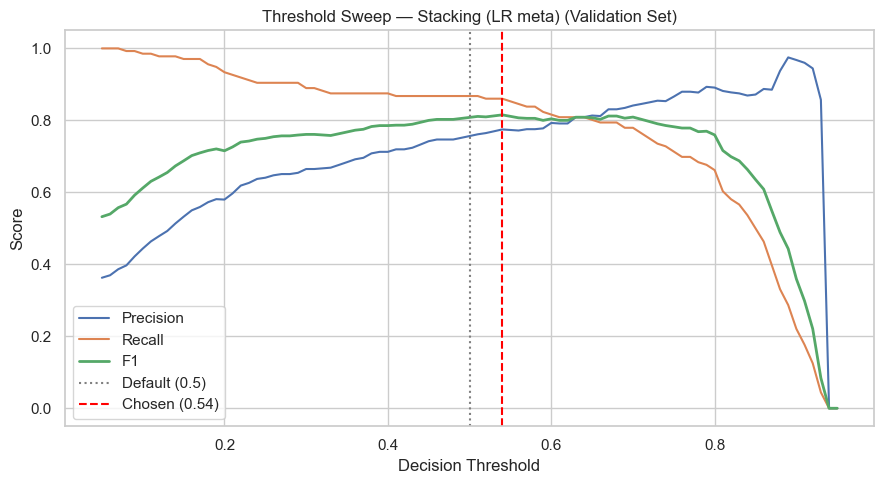

F1-optimal threshold: 0.54  (default is 0.5)


In [13]:
winner_val_proba = fusion_proba(best_fusion_name, churn_proba_val, sent_score_val)

thresholds = np.arange(0.05, 0.96, 0.01)
prec_list, rec_list, f1_list = [], [], []
for t in thresholds:
    pred_t = (winner_val_proba >= t).astype(int)
    prec_list.append(precision_score(y_val, pred_t, zero_division=0))
    rec_list.append(recall_score(y_val, pred_t, zero_division=0))
    f1_list.append(f1_score(y_val, pred_t, zero_division=0))

best_idx = int(np.argmax(f1_list))
BEST_THRESHOLD = round(float(thresholds[best_idx]), 2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, prec_list, label='Precision')
ax.plot(thresholds, rec_list, label='Recall')
ax.plot(thresholds, f1_list, label='F1', linewidth=2)
ax.axvline(0.5, color='gray', linestyle=':', label='Default (0.5)')
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Chosen ({BEST_THRESHOLD})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Sweep — {best_fusion_name} (Validation Set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'F1-optimal threshold: {BEST_THRESHOLD}  (default is 0.5)')

In [14]:
with open('models/churn_threshold.json') as f:
    churn_threshold_info = json.load(f)
CHURN_ALONE_THRESHOLD = churn_threshold_info['threshold']

winner_test_proba = fusion_proba(best_fusion_name, churn_proba_test, sent_score_test)
winner_pred_default = (winner_test_proba >= 0.5).astype(int)
winner_pred_tuned    = (winner_test_proba >= BEST_THRESHOLD).astype(int)

# Churn-alone baseline shown at its own tuned operating threshold — the fairest
# real-world comparison point, since that's what churn_model.ipynb actually recommends.
churn_alone_pred = (churn_proba_test >= CHURN_ALONE_THRESHOLD).astype(int)

print(f'Winning fusion strategy: {best_fusion_name}')
print(f'Churn model alone — using its own tuned threshold ({CHURN_ALONE_THRESHOLD}):')
print(classification_report(y_test, churn_alone_pred, target_names=['Retained', 'Churned']))

print(f'{best_fusion_name} — default threshold (0.5):')
print(classification_report(y_test, winner_pred_default, target_names=['Retained', 'Churned']))

print(f'{best_fusion_name} — tuned threshold ({BEST_THRESHOLD}):')
print(classification_report(y_test, winner_pred_tuned, target_names=['Retained', 'Churned']))

Winning fusion strategy: Stacking (LR meta)
Churn model alone — using its own tuned threshold (0.56):
              precision    recall  f1-score   support

    Retained       0.89      0.92      0.90       239
     Churned       0.84      0.80      0.82       137

    accuracy                           0.87       376
   macro avg       0.87      0.86      0.86       376
weighted avg       0.87      0.87      0.87       376

Stacking (LR meta) — default threshold (0.5):
              precision    recall  f1-score   support

    Retained       0.90      0.91      0.90       239
     Churned       0.84      0.82      0.83       137

    accuracy                           0.88       376
   macro avg       0.87      0.87      0.87       376
weighted avg       0.88      0.88      0.88       376

Stacking (LR meta) — tuned threshold (0.54):
              precision    recall  f1-score   support

    Retained       0.89      0.92      0.90       239
     Churned       0.85      0.81      0.83 

In [15]:
final_results = [
    evaluate('Churn model alone (tuned)', y_test, churn_alone_pred, churn_proba_test),
    evaluate(f'{best_fusion_name} (default)', y_test, winner_pred_default, winner_test_proba),
    evaluate(f'{best_fusion_name} (tuned)', y_test, winner_pred_tuned, winner_test_proba),
]
final_results_df = pd.DataFrame(final_results)
final_results_df

,Model,Accuracy,F1,F2,ROC-AUC,PR-AUC
0,Churn model alone (tuned),0.8723,0.8195,0.8050,0.9370,0.9141
1,Stacking (LR meta) (default),0.8777,0.8309,0.8272,0.9383,0.9162
2,Stacking (LR meta) (tuned),0.8777,0.8284,0.8174,0.9383,0.9162


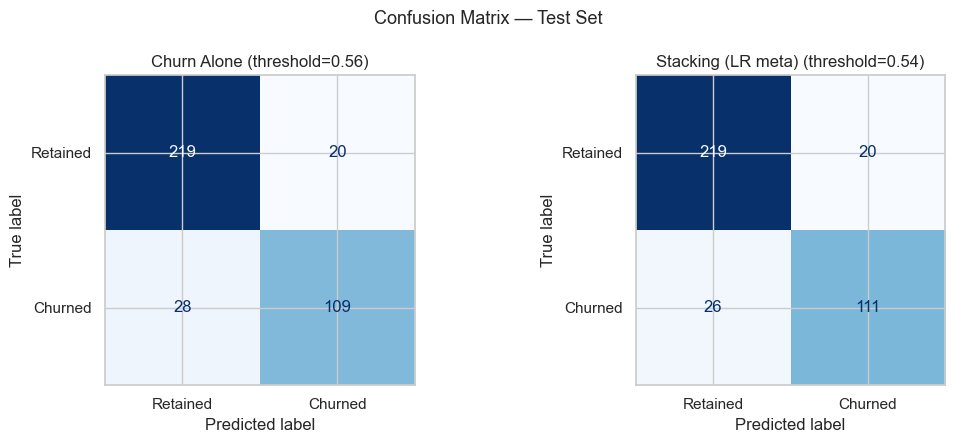

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, preds, title in [
    (axes[0], churn_alone_pred, f'Churn Alone (threshold={CHURN_ALONE_THRESHOLD})'),
    (axes[1], winner_pred_tuned, f'{best_fusion_name} (threshold={BEST_THRESHOLD})'),
]:
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.suptitle('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
out = test[[ID_COL, TEXT_COL]].copy()
out['Sentiment']            = sent_pred_test
out['Sentiment_Score']      = sent_score_test
out['Churn_Proba_Model']    = churn_proba_test.round(4)
out['Churn_Pred_Model']     = churn_alone_pred
out[f'{best_fusion_name}_Proba']         = winner_test_proba.round(4)
out[f'{best_fusion_name}_Pred_Default']  = winner_pred_default
out[f'{best_fusion_name}_Pred_Tuned']    = winner_pred_tuned
out['Actual_Churn']         = y_test.values

out.to_csv('Datasets/late_fusion_predictions.csv', index=False)
print('Saved → Datasets/late_fusion_predictions.csv')
out.head(10)

Saved → Datasets/late_fusion_predictions.csv


,Customer_ID,Review,Sentiment,Sentiment_Score,Churn_Proba_Model,Churn_Pred_Model,Stacking (LR meta)_Proba,Stacking (LR meta)_Pred_Default,Stacking (LR meta)_Pred_Tuned,Actual_Churn
0,2703eb5f-acf1-4e1c-a177-0729262ef43a,Budget conversations about the admin console h...,Satisfied,0.173037,0.0833,0,0.0866,0,0,0
1,dc8b4df2-fb8e-4c44-b8a9-982aff091864,Our IT team asked how to set up conditional lo...,Satisfied,0.388962,0.8935,1,0.7994,1,1,1
2,adce29e5-8343-43c1-8f96-1af5aa1cd569,Our engineering lead migrated a big workload o...,Frustrated,0.520924,0.0076,0,0.1099,0,0,0
3,f36467fe-248d-415f-9f06-b1c9e64dbc06,Our department head asked how to set up condit...,Satisfied,0.072857,0.1072,0,0.0813,0,0,0
4,50b1a5a7-79e7-48c7-b318-d33c8b2aaaa5,The renewal price increase on customer support...,Frustrated,0.624822,0.3323,0,0.3626,0,0,0
5,ddb9f772-20f6-434a-bfce-bcc5d841915a,We've had repeated failed uploads on the notif...,Frustrated,0.793412,0.0407,0,0.1826,0,0,0
6,b0fed901-e8fc-49ba-bab9-225264d4cab3,Our ops lead expected better account managemen...,Satisfied,0.411225,0.9775,1,0.8544,1,1,1
7,cbab31b6-3e86-4d89-b16e-5aa40073d29a,"The billing system works fine overall, though ...",Neutral,0.454775,0.6406,1,0.6077,1,1,0
8,9def4953-1b96-4bfd-a330-deddaf94a4d9,A growing team has been blocked by session tim...,Neutral,0.695854,0.9709,1,0.9018,1,1,1
9,c8670269-594c-4c39-a14d-f7d4b12508c8,A small team switched from a lower-cost compet...,Satisfied,0.132356,0.7919,1,0.6296,1,1,1


In [18]:
os.makedirs('models', exist_ok=True)

artifacts = {
    'best_churn_model':     best_churn_path,
    'best_sentiment_model': best_sent_path,
    'fusion_strategy':      best_fusion_name,
    'alpha':                best_alpha,
    'threshold':            BEST_THRESHOLD,
}
with open('models/fusion_config.json', 'w') as f:
    json.dump(artifacts, f, indent=2)
print('Fusion config saved → models/fusion_config.json')
print(json.dumps(artifacts, indent=2))

if best_fusion_name == 'Stacking (LR meta)':
    joblib.dump(meta_clf, 'models/fusion_meta_classifier.pkl')
    print('Meta-classifier saved → models/fusion_meta_classifier.pkl')

Fusion config saved → models/fusion_config.json
{
  "best_churn_model": "models\\churn_gradient_boosting.pkl",
  "best_sentiment_model": "models\\sentiment_naive_bayes.pkl",
  "fusion_strategy": "Stacking (LR meta)",
  "alpha": 0.75,
  "threshold": 0.54
}
Meta-classifier saved → models/fusion_meta_classifier.pkl
